### 方針
・一旦予測まで終わらせるために、missingnoで白が多いところは弾く<br>
<br>
対象：Alley, MasVnrType, FireplaceQu, PoolQC, Fence, MiscFeature<br>
<br>
<br>
・多少白があるところをどう補完したりするか<br>
LotFrontage - NAを0に変換<br>
MasVnrArea - MasVnrTypeを弾いてるから弾く<br>
BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF - 地下室関連は一旦除外<br>
Electrical - 1か所だけ入力漏れか何かでNAになってるからその行だけ削除<br>
GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond - ガレージ関連は一旦除外<br>

In [1]:
import pandas as pd
import missingno as msno

from sklearn.preprocessing import LabelEncoder

In [2]:
train = pd.read_csv("train.csv")

<Axes: >

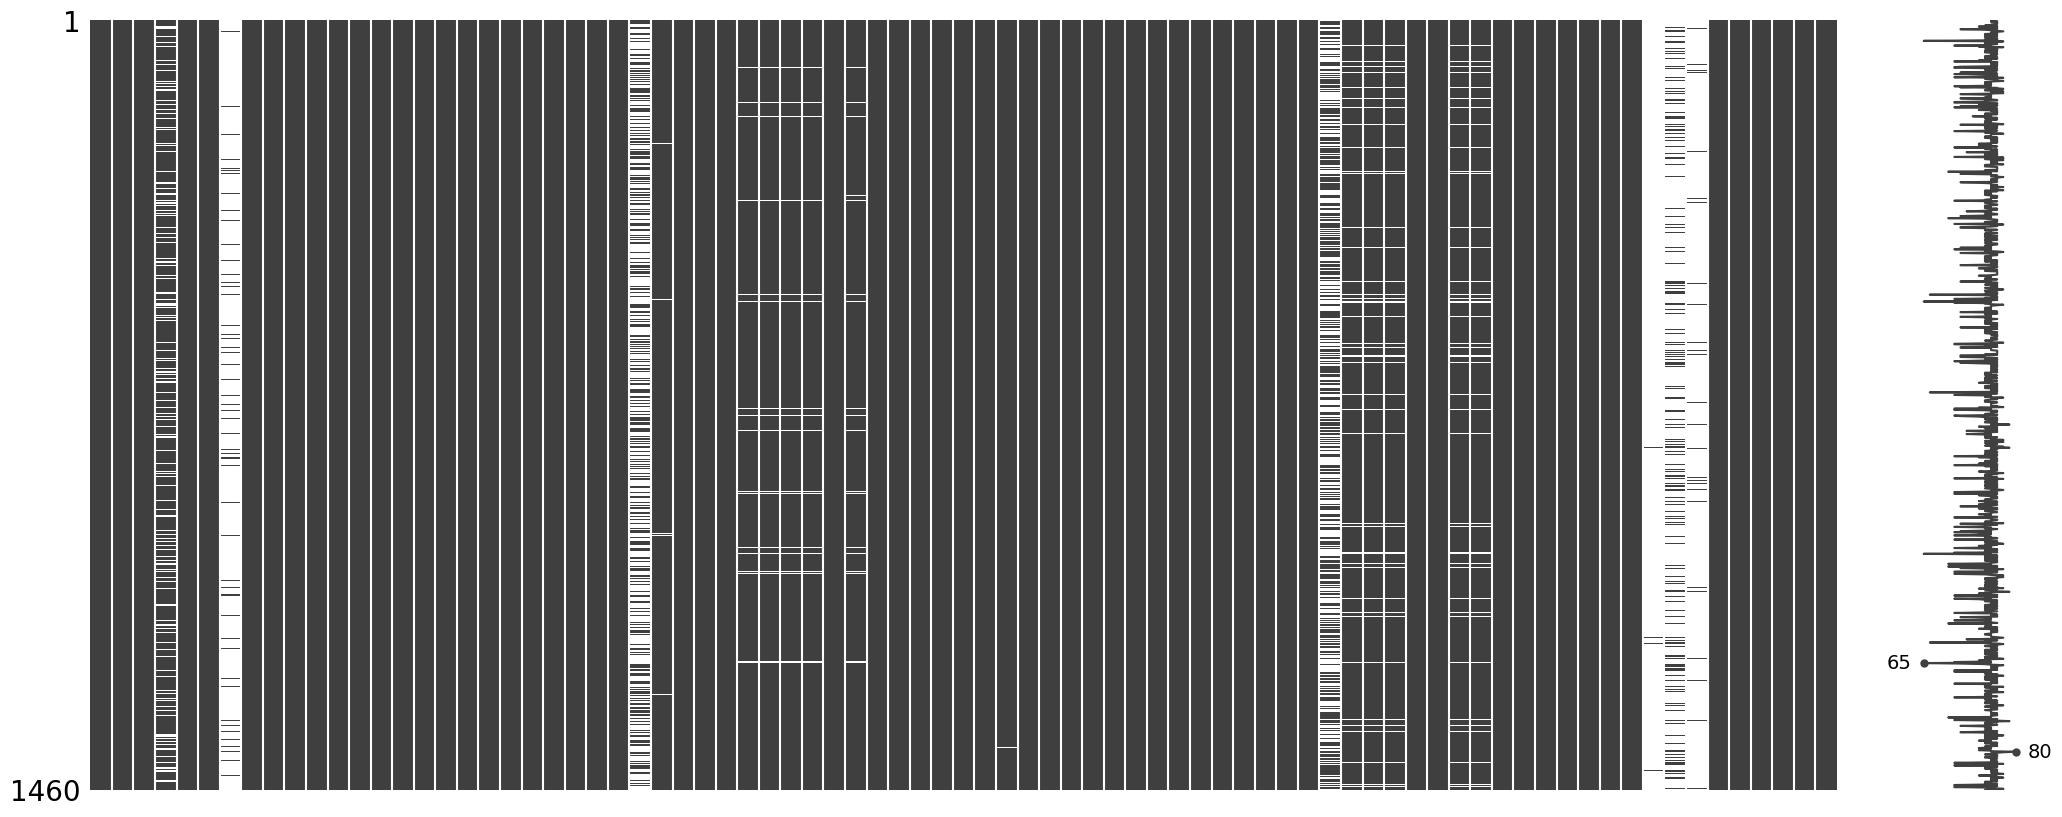

In [3]:
msno.matrix(train)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
#Alley, MasVnrType, FireplaceQu, PoolQC, Fence, MiscFeature, MasVnrAreaを落とす
pre_data = train.drop(columns=["Alley", "MasVnrType", "FireplaceQu", "PoolQC", "Fence", "MiscFeature", "MasVnrArea"])

In [6]:
#LotFrontage - NAを0に変換
pre_data["LotFrontage"] = pre_data["LotFrontage"].fillna(0)

In [7]:
#BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF - 地下室関連は一旦除外
pre_data = pre_data.drop(columns=["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinSF1", "BsmtFinType2", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF"])

In [8]:
#Electrical - 1か所だけ入力漏れか何かでNAになってるからその行だけ削除
pre_data = pre_data.dropna(subset=["Electrical"])

In [9]:
#GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond - ガレージ関連は一旦除外
pre_data = pre_data.drop(columns=["GarageType", "GarageYrBlt", "GarageFinish", "GarageQual", "GarageCond"])

In [10]:
#CentralAirはYesとNoだけだから1と0に変換
pre_data["CentralAir"] = pre_data["CentralAir"].map({"Y": 1, "N": 0})

In [11]:
pre_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 0 to 1459
Data columns (total 60 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1459 non-null   object 
 3   LotFrontage    1459 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1459 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuilt    

<Axes: >

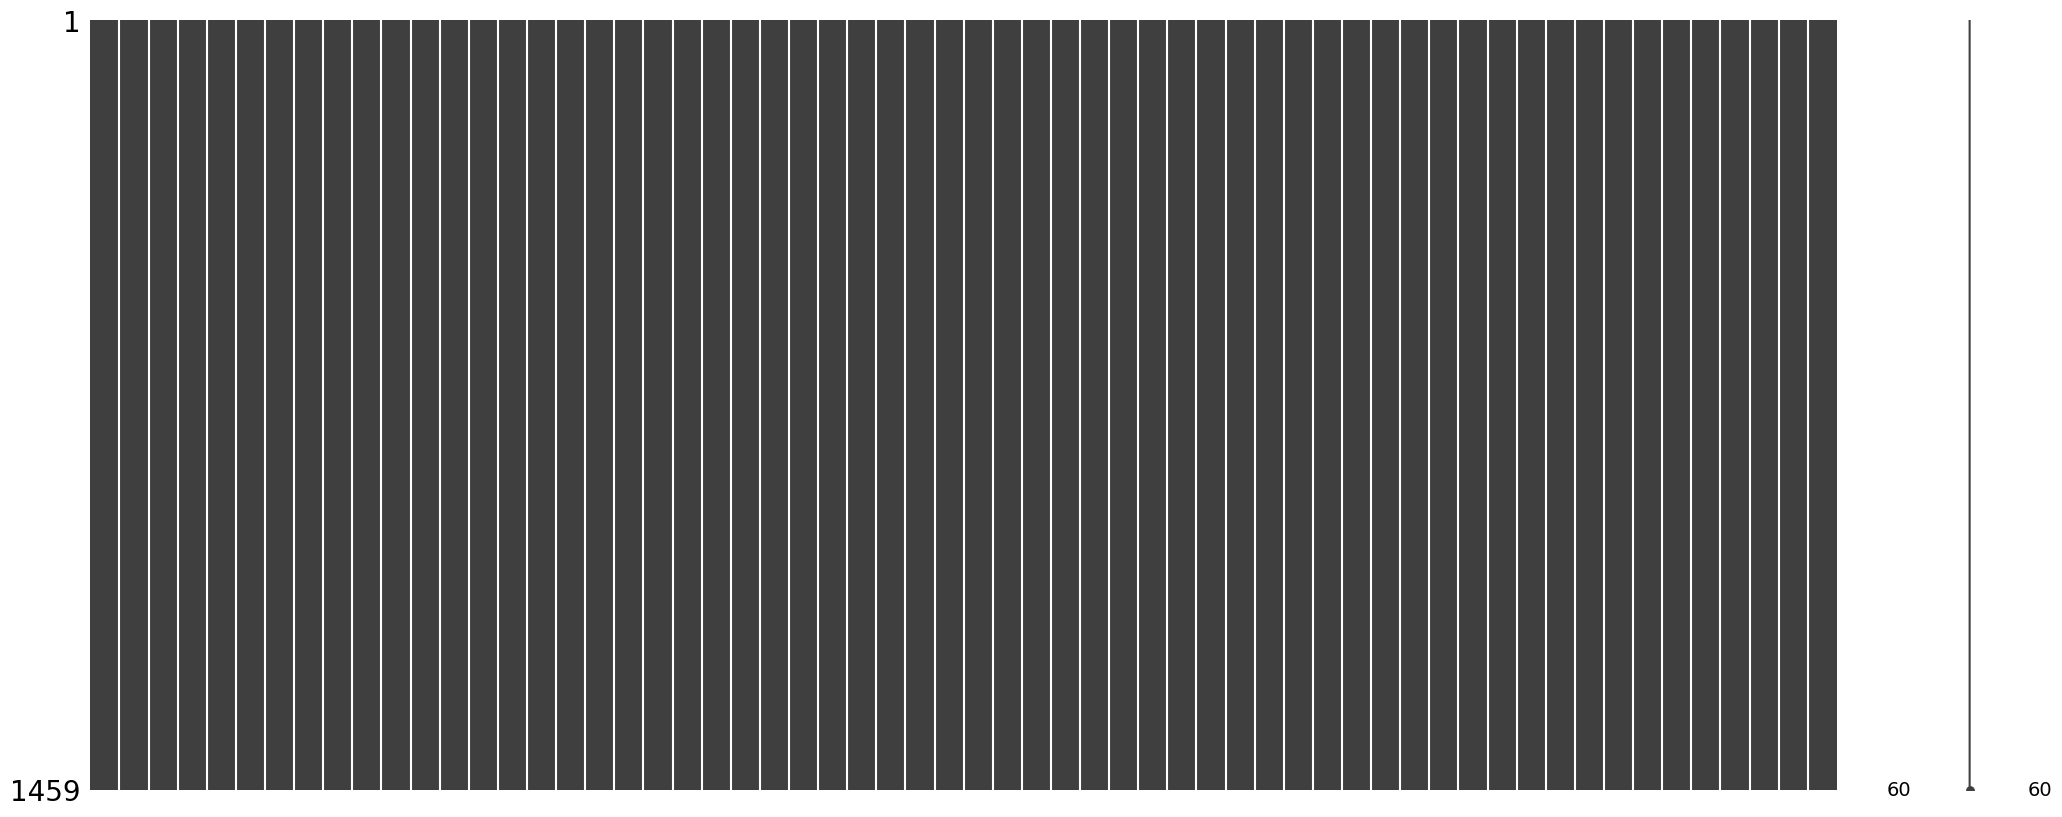

In [12]:
msno.matrix(pre_data)

In [13]:
pre_data.to_csv("pre_data.csv", index=False)

In [14]:
#文字エンコード
#MSZoning, Street, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, ExterQual, ExterCond, Foundation, Heating, HeatingQC, Electrical, KitchenQual, Functional, PavedDrive, SaleType, SaleCondition
categorical_columns = ["MSZoning", "Street", "LotShape", "LandContour", "Utilities", "LotConfig", "LandSlope", "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "ExterQual", "ExterCond", "Foundation", "Heating", "HeatingQC", "Electrical", "KitchenQual", "Functional", "PavedDrive", "SaleType", "SaleCondition"]

In [15]:
label_encoder = LabelEncoder()

In [16]:
label_encoders = {}
for col in categorical_columns:
    label_encoders[col] = LabelEncoder()
    pre_data[col] = label_encoders[col].fit_transform(pre_data[col])

In [17]:
pre_data.to_csv("pre_data_encode.csv", index=False)

In [18]:
pre_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 0 to 1459
Data columns (total 60 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1459 non-null   int32  
 3   LotFrontage    1459 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   int32  
 6   LotShape       1459 non-null   int32  
 7   LandContour    1459 non-null   int32  
 8   Utilities      1459 non-null   int32  
 9   LotConfig      1459 non-null   int32  
 10  LandSlope      1459 non-null   int32  
 11  Neighborhood   1459 non-null   int32  
 12  Condition1     1459 non-null   int32  
 13  Condition2     1459 non-null   int32  
 14  BldgType       1459 non-null   int32  
 15  HouseStyle     1459 non-null   int32  
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuilt    